Plot: \
1.PSD \
2.w spectrum/phase spectrum \
3.Angle spectrum \
\
for signal that is: \
a) Normal \
b) Upscaled \
c) Downscaled \
d) Zero Pading

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

## 1. Ploting Normal Signal

### Create signal
1 * sin 5Hz + 0.5 * cos 15Hz

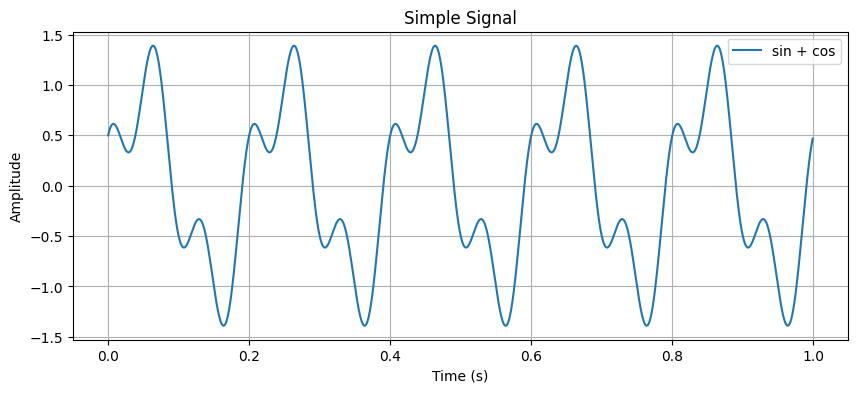

In [134]:
# Sampling parameters
fs = 1050  # Sampling frequency (Hz)
T = 1      # Duration (seconds)
t = np.linspace(0, T, fs*T, endpoint=False)  # Time vector

# Define frequencies and amplitudes
f1, f2 = 5, 15  # Hz
A1, A2 = 1.0, 0.5  # Amplitudes

# Create signal: sum of sin and cos
simple_signal = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.cos(2 * np.pi * f2 * t)

# Plot the signal
plt.figure(figsize=(10, 4))
plt.plot(t, simple_signal, label="sin + cos")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simple Signal")
plt.legend()
plt.grid(True)
plt.show()


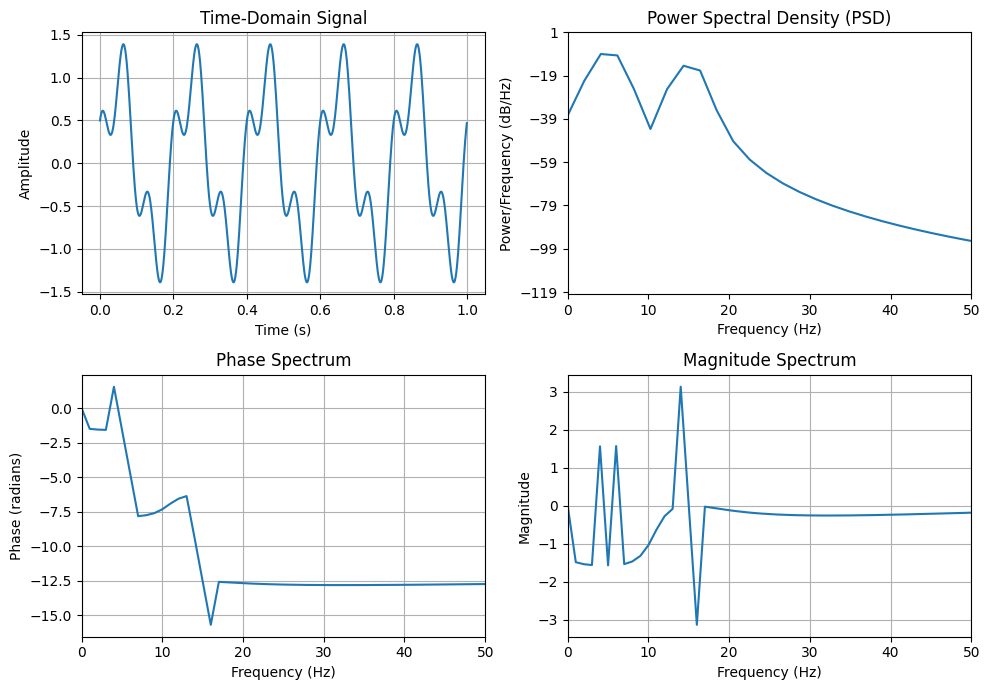

In [135]:
# Plot all four representations
fig, axs = plt.subplots(2, 3, figsize=(10, 7))

# Plot the signal (Time-Domain)
axs[0, 0].plot(t, simple_signal)
axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].set_title("Time-Domain Signal")
axs[0, 0].grid()

# Power Spectral Density (PSD)
axs[0, 1].psd(simple_signal, NFFT=512, Fs=fs)

axs[0, 1].set_ylim(bottom=-120)
axs[0, 1].set_xlim(0, 50)
axs[0, 1].set_xlabel("Frequency (Hz)")
axs[0, 1].set_ylabel("Power/Frequency (dB/Hz)")
axs[0, 1].set_title("Power Spectral Density (PSD)")
axs[0, 1].grid()

# Phase Spectrum
axs[1, 0].phase_spectrum(simple_signal, Fs=fs)
axs[1, 0].set_xlim(0, 50)
axs[1, 0].set_xlabel("Frequency (Hz)")
axs[1, 0].set_ylabel("Phase (radians)")
axs[1, 0].set_title("Phase Spectrum")
axs[1, 0].grid()

# Angle Spectrum (Equivalent to Phase Spectrum)
axs[1, 1].angle_spectrum(simple_signal, Fs=fs)
axs[1, 1].set_xlim(0, 50)
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_ylabel("Magnitude")
axs[1, 1].set_title("Magnitude Spectrum")
axs[1, 1].grid()

# Adjust layout
plt.tight_layout()
plt.show()


## 2.Signal Transformation

### 2.1 Upscaled

In [136]:
# Define upscale factor
upscale_factor = 2
num_samples_new = len(simple_signal) * upscale_factor  # New number of samples

# Resample the signal
signal_upscaled = resample(simple_signal, num_samples_new)

# New time vector
t_upscaled = np.linspace(0, T, num_samples_new, endpoint=False)

upscaled_fs = fs * 2
len(signal_upscaled)

2100

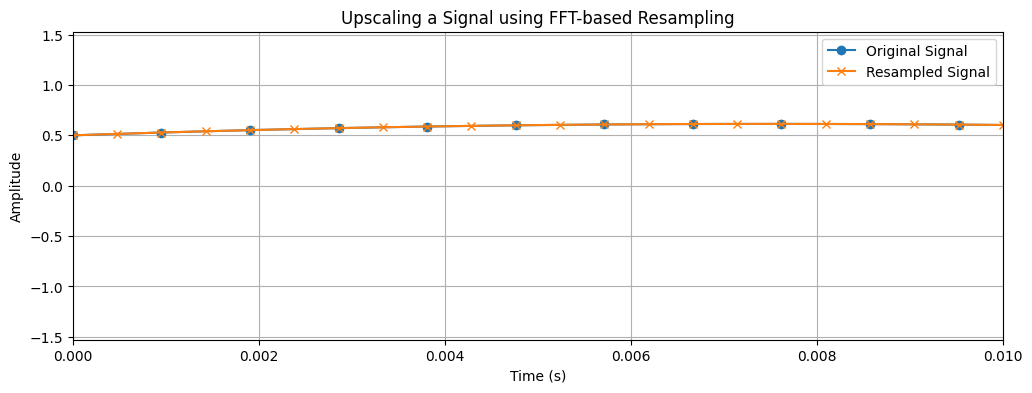

In [137]:
# Plot original vs resampled
plt.figure(figsize=(12, 4))
plt.plot(t, simple_signal, 'o-', label="Original Signal")
plt.plot(t_upscaled, signal_upscaled, 'x-', label="Resampled Signal")
plt.xlim(0, 0.01)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Upscaling a Signal using FFT-based Resampling")
plt.legend()
plt.grid()
plt.show()

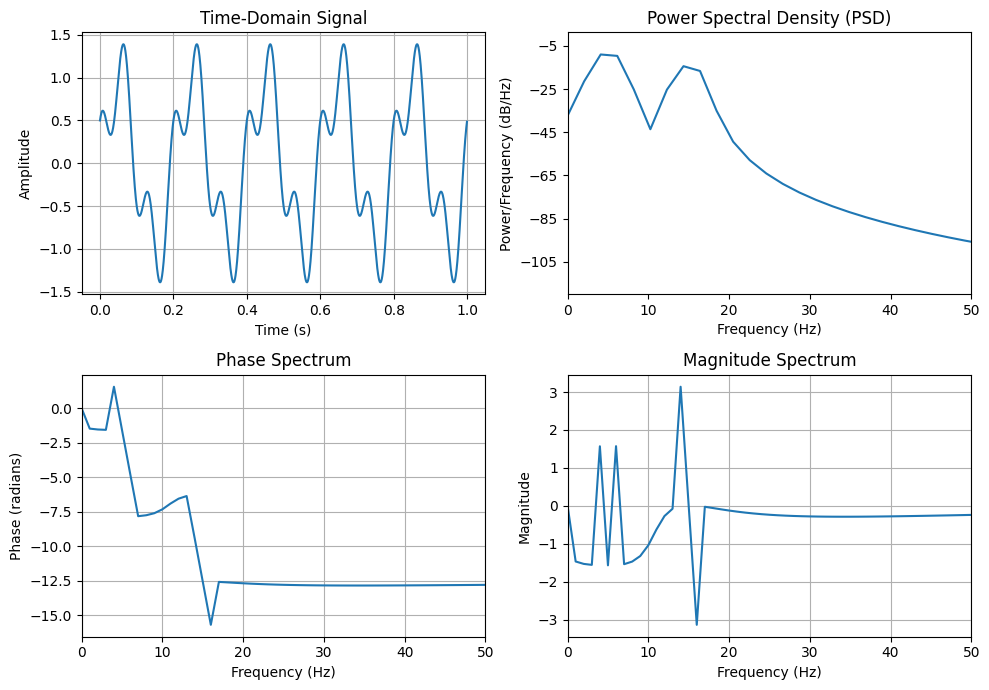

In [138]:
# Plot all four representations
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

# Plot the signal (Time-Domain)
axs[0, 0].plot(t_upscaled, signal_upscaled)

axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].set_title("Time-Domain Signal")
axs[0, 0].grid()

# Power Spectral Density (PSD)
axs[0, 1].psd(signal_upscaled, NFFT=1024, Fs=upscaled_fs)

axs[0, 1].set_ylim(bottom=-120)
axs[0, 1].set_xlim(0, 50)
axs[0, 1].set_xlabel("Frequency (Hz)")
axs[0, 1].set_ylabel("Power/Frequency (dB/Hz)")
axs[0, 1].set_title("Power Spectral Density (PSD)")
axs[0, 1].grid()

# Phase Spectrum
axs[1, 0].phase_spectrum(signal_upscaled, Fs=upscaled_fs)

axs[1, 0].set_xlim(0, 50)
axs[1, 0].set_xlabel("Frequency (Hz)")
axs[1, 0].set_ylabel("Phase (radians)")
axs[1, 0].set_title("Phase Spectrum")
axs[1, 0].grid()

# Angle Spectrum (Equivalent to Phase Spectrum)
axs[1, 1].angle_spectrum(signal_upscaled, Fs=upscaled_fs)

axs[1, 1].set_xlim(0, 50)
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_ylabel("Magnitude")
axs[1, 1].set_title("Magnitude Spectrum")
axs[1, 1].grid()

# Adjust layout
plt.tight_layout()
plt.show()


### 2.2 Downscaling

In [139]:
# Define upscale factor
upscale_factor = 1/2
num_samples_new = int(len(simple_signal) * upscale_factor)  # New number of samples

# Resample the signal
signal_downscaled = resample(simple_signal, num_samples_new)

# New time vector
t_downscaled = np.linspace(0, T, num_samples_new, endpoint=False)

downscaled_fs = int(fs * 1/2)
len(signal_downscaled)

525

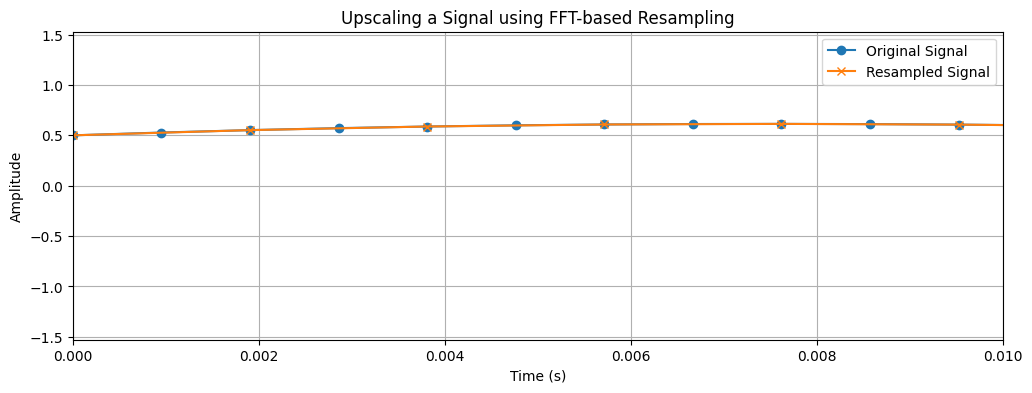

In [140]:
# Plot original vs resampled
plt.figure(figsize=(12, 4))
plt.plot(t, simple_signal, 'o-', label="Original Signal")
plt.plot(t_downscaled, signal_downscaled, 'x-', label="Resampled Signal")
plt.xlim(0, 0.01)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Upscaling a Signal using FFT-based Resampling")
plt.legend()
plt.grid()
plt.show()

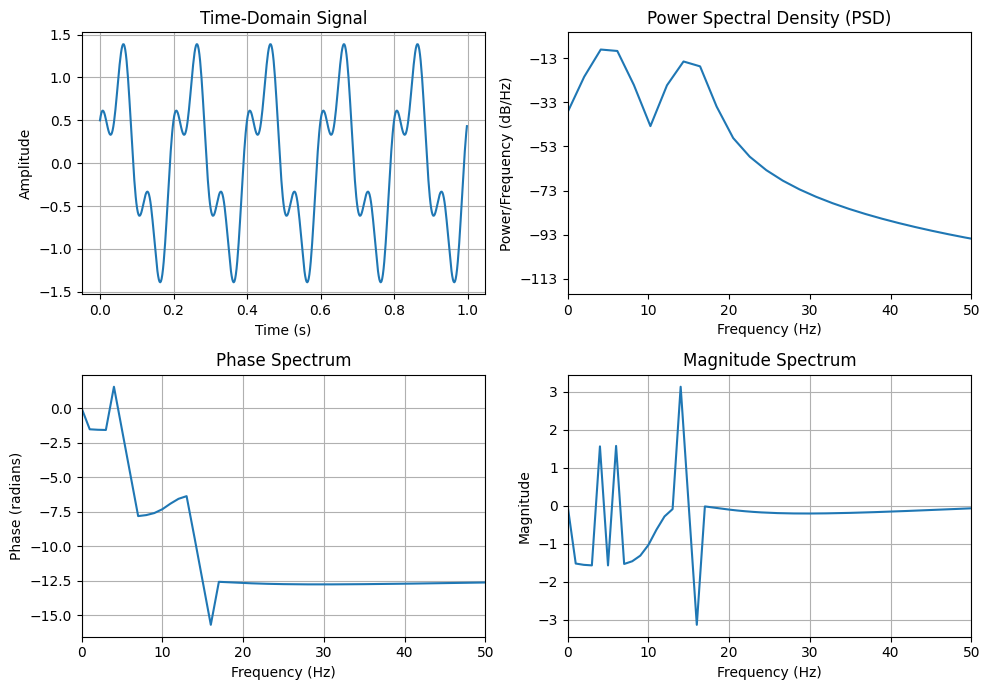

In [141]:
# Plot all four representations
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

# Plot the signal (Time-Domain)
axs[0, 0].plot(t_downscaled, signal_downscaled)

axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].set_title("Time-Domain Signal")
axs[0, 0].grid()

# Power Spectral Density (PSD)
axs[0, 1].psd(signal_downscaled, NFFT=256, Fs=downscaled_fs)

axs[0, 1].set_ylim(bottom=-120)
axs[0, 1].set_xlim(0, 50)
axs[0, 1].set_xlabel("Frequency (Hz)")
axs[0, 1].set_ylabel("Power/Frequency (dB/Hz)")
axs[0, 1].set_title("Power Spectral Density (PSD)")
axs[0, 1].grid()

# Phase Spectrum
axs[1, 0].phase_spectrum(signal_downscaled, Fs=downscaled_fs)

axs[1, 0].set_xlim(0, 50)
axs[1, 0].set_xlabel("Frequency (Hz)")
axs[1, 0].set_ylabel("Phase (radians)")
axs[1, 0].set_title("Phase Spectrum")
axs[1, 0].grid()

# Angle Spectrum (Equivalent to Phase Spectrum)
axs[1, 1].angle_spectrum(signal_downscaled, Fs=downscaled_fs)

axs[1, 1].set_xlim(0, 50)
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_ylabel("Magnitude")
axs[1, 1].set_title("Magnitude Spectrum")
axs[1, 1].grid()

# Adjust layout
plt.tight_layout()
plt.show()


## 2.3 Zero padding

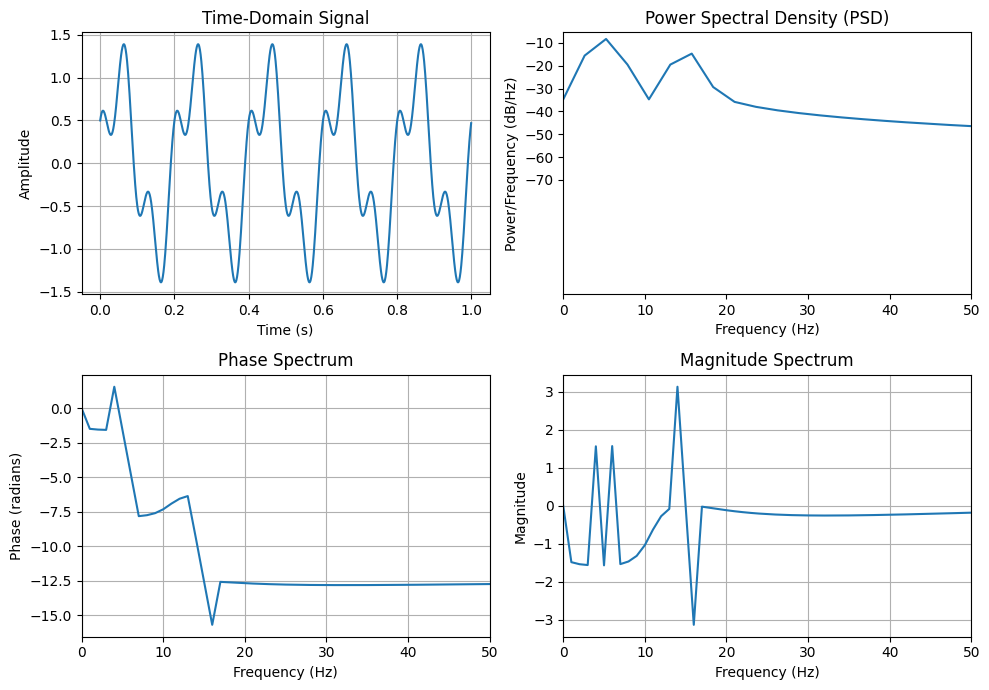

In [142]:
# Plot all four representations
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

# Plot the signal (Time-Domain)
axs[0, 0].plot(t, simple_signal)

axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].set_title("Time-Domain Signal")
axs[0, 0].grid()

# Power Spectral Density (PSD)
axs[0, 1].psd(simple_signal, NFFT=512, Fs=fs, pad_to=400)

axs[0, 1].set_ylim(bottom=-120)
axs[0, 1].set_xlim(0, 50)
axs[0, 1].set_xlabel("Frequency (Hz)")
axs[0, 1].set_ylabel("Power/Frequency (dB/Hz)")
axs[0, 1].set_title("Power Spectral Density (PSD)")
axs[0, 1].grid()

# Phase Spectrum
axs[1, 0].phase_spectrum(simple_signal, Fs=fs)

axs[1, 0].set_xlim(0, 50)
axs[1, 0].set_xlabel("Frequency (Hz)")
axs[1, 0].set_ylabel("Phase (radians)")
axs[1, 0].set_title("Phase Spectrum")
axs[1, 0].grid()

# Angle Spectrum (Equivalent to Phase Spectrum)
axs[1, 1].angle_spectrum(simple_signal, Fs=fs)

axs[1, 1].set_xlim(0, 50)
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_ylabel("Magnitude")
axs[1, 1].set_title("Magnitude Spectrum")
axs[1, 1].grid()

# Adjust layout
plt.tight_layout()
plt.show()


### 2.3 Comparison of PSD

In [143]:
def create_scatter_PSD(ax, signal, fs, NFFT=512, pad_to=None):
    if pad_to is None:
        pad_to = NFFT
    ax.psd(signal, linestyle='', NFFT=NFFT, Fs=fs, pad_to=pad_to)
    lines = ax.get_lines()
    line = lines[0]

    xdata = line.get_xdata()
    ydata = line.get_ydata()

    ax.scatter(xdata, ydata, s=7.5)
    
    ax.set_xlim(0, 50)
    ax.set_ylim(bottom=-120)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power/Frequency (dB/Hz)")
    ax.set_title("Power Spectral Density (PSD)")
    
    
    return ax

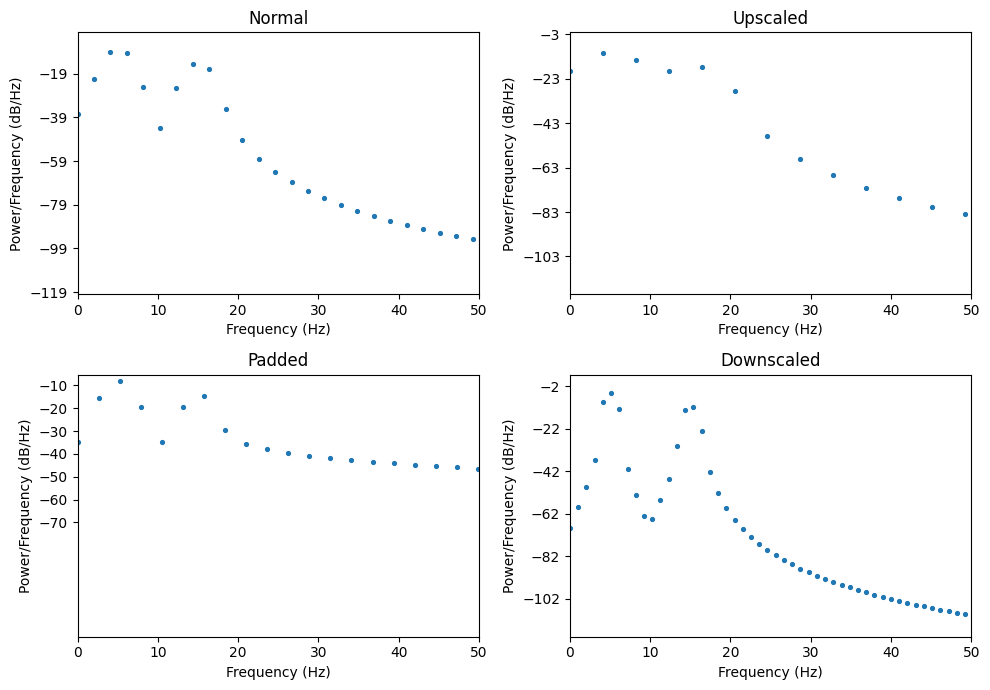

In [144]:
# Plot all four representations
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

# Normal PSD
axs[0, 0] = create_scatter_PSD(axs[0, 0], simple_signal, fs)
axs[0, 0].set_title("Normal")
axs[0, 0].grid()

# Upscaled PSD
axs[0, 1] = create_scatter_PSD(axs[0, 1], signal_upscaled, upscaled_fs)
axs[0, 1].set_title("Upscaled")
axs[0, 1].grid()

# Padded PSD
axs[1, 0] = create_scatter_PSD(axs[1, 0], simple_signal, fs, pad_to=400)
axs[1, 0].set_title("Padded")
axs[1, 0].grid()

# Downscaled PSD
axs[1, 1] = create_scatter_PSD(axs[1, 1], signal_downscaled, downscaled_fs)
axs[1, 1].set_title("Downscaled")
axs[1, 1].grid()

# Adjust layout
plt.tight_layout()
plt.show()
